# Superstore Sales Analysis & Profitability Prediction

## Project Overview

This project analyzes over 51,000 sales transactions to uncover
business insights related to sales performance, profitability,
customer behavior, and future sales trends.

The project uses Python, Pandas, NumPy, Matplotlib, and Scikit-learn
to perform data cleaning, exploratory data analysis, feature
engineering, customer segmentation, machine learning, and sales
forecasting.

### Key Objectives

- Analyze sales and profit performance
- Identify top-performing products and regions
- Understand the relationship between discount and profit
- Segment customers using RFM analysis
- Predict whether an order will be profitable
- Forecast future sales using historical trends
- Provide actionable business recommendations

## Table of Contents

1. [Data Loading](#1-data-loading)
2. [Data Cleaning](#2-data-cleaning)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Customer Analysis & RFM](#5-customer-analysis--rfm)
6. [Machine Learning](#6-machine-learning)
7. [Sales Forecasting](#7-sales-forecasting)
8. [Business Insights & Recommendations](#8-business-insights--recommendations)
9. [Final Conclusion](#9-final-conclusion)

# 1. Data Loading

In [1]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
store =pd.read_csv('C:/data science/data science real time projects/project 1 Sales Data Analysis/SuperStoreOrders.csv/SuperStoreOrders.csv')
print(store.head())
print(store.head(2))

          order_id order_date ship_date       ship_mode    customer_name  \
0     AG-2011-2040   1/1/2011  6/1/2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   
2     HU-2011-1220   1/1/2011  5/1/2011    Second Class    Annie Thurman   
3  IT-2011-3647632   1/1/2011  5/1/2011    Second Class     Eugene Moren   
4    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name sales quantity  \
0  Office Supplies      Storage          Tenex Lockers,

In [ ]:
print(store.info())
print(store.columns)

print(store.shape)
print(store.describe())

# 2. Data Cleaning

In [3]:
print(store.isnull().sum())


order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64


In [7]:
#check duplicates
 

print(store.duplicated().sum())

0


In [6]:
#check datatypes

print(store.dtypes)

order_id              str
order_date            str
ship_date             str
ship_mode             str
customer_name         str
segment               str
state                 str
country               str
market                str
region                str
product_id            str
category              str
sub_category          str
product_name          str
sales                 str
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority        str
year                int64
dtype: object


In [8]:
store['order_date']=pd.to_datetime(store['order_date'],format='mixed')
store['ship_date']=pd.to_datetime(store['ship_date'],format='mixed')
store['sales']=store['sales'].str.replace(',','').astype(float)

In [9]:
print(store['sales'].head())

0    408.0
1    120.0
2     66.0
3     45.0
4    114.0
Name: sales, dtype: float64


In [10]:
#sales outlier
Q1=store['sales'].quantile(0.25)
Q3=store['sales'].quantile(0.75)

iqr=Q3-Q1

lower_bound=Q1-1.5*iqr
upper_bound=Q3+1.5*iqr
print("Q1:",Q1)
print("Q3:",Q3)
print("iqr:",iqr)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)

Q1: 31.0
Q3: 251.0
iqr: 220.0
lower_bound: -299.0
upper_bound: 581.0


# 3. Exploratory Data Analysis

          category      sales
0        Furniture  4110884.0
1  Office Supplies  3787330.0
2       Technology  4744691.0


Text(0, 0.5, 'Total Sales')

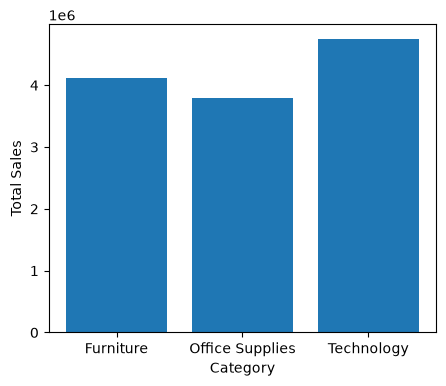

In [11]:
# 1,sales by category 

category_sales=store.groupby('category')['sales'].sum().reset_index()
print(category_sales)

plt.figure(figsize=(5,4
))
plt.bar(category_sales['category'],category_sales['sales'])
plt.xlabel('Category')
plt.ylabel('Total Sales')

finding: Technology is the strongest category in terms of sales. 

            region      sales
0          Central  2822399.0
1            South  1600960.0
2            North  1248192.0
3          Oceania  1100207.0
4   Southeast Asia   884438.0
5       North Asia   848349.0
6             EMEA   806184.0
7           Africa   783776.0
8     Central Asia   752839.0
9             West   725514.0
10            East   678834.0
11       Caribbean   324281.0
12          Canada    66932.0


<Figure size 800x500 with 0 Axes>

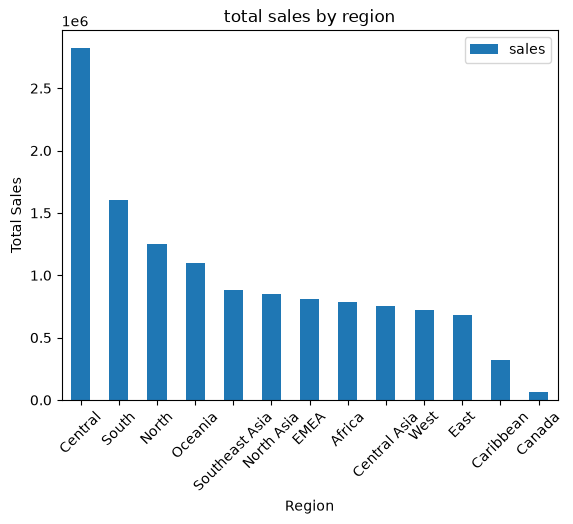

In [12]:
#2,Which region generates the most sales?

region_sales=store.groupby('region')['sales'].sum().sort_values(ascending=False).reset_index()
print(region_sales)


plt.figure(figsize=(8,5))
region_sales.plot(kind='bar',x="region",y="sales")
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.title('total sales by region')
plt.show()

finding: Central is the strongest region by sales.

    month      sales
0       1   775794.0
1       2   722888.0
2       3   951379.0
3       4   851641.0
4       5   976429.0
5       6  1152392.0
6       7   838761.0
7       8  1247542.0
8       9  1244201.0
9      10  1120810.0
10     11  1377692.0
11     12  1383376.0


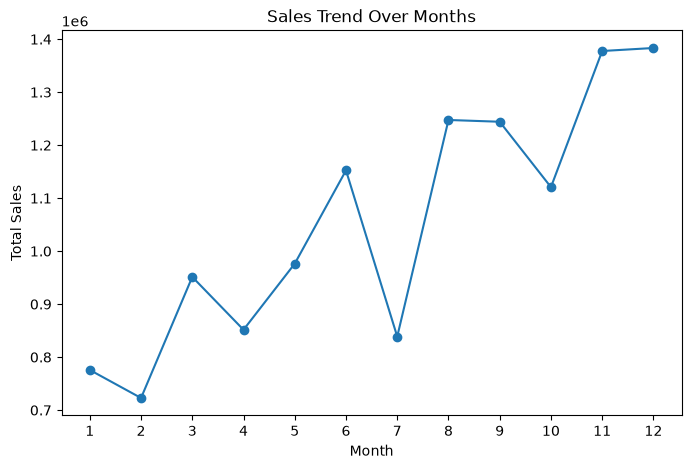

In [13]:
#3,Monthly Sales Trend

store['month']=store['order_date'].dt.month
sales_trend=store.groupby('month')['sales'].sum().reset_index()
print(sales_trend)

plt.figure(figsize=(8, 5))
plt.plot(sales_trend['month'], sales_trend['sales'], marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Sales Trend Over Months')
plt.xticks(range(1, 13))
plt.show()

finding: November and December were particularly strong sales months.

                                        product_name    sales
0                       Apple Smart Phone, Full Size  86936.0
1                       Cisco Smart Phone, Full Size  76441.0
2                    Motorola Smart Phone, Full Size  73159.0
3                       Nokia Smart Phone, Full Size  71904.0
4              Canon imageCLASS 2200 Advanced Copier  61600.0
5         Hon Executive Leather Armchair, Adjustable  58200.0
6  Office Star Executive Leather Armchair, Adjust...  50667.0
7  Harbour Creations Executive Leather Armchair, ...  50120.0
8                      Samsung Smart Phone, Cordless  48654.0
9                  Nokia Smart Phone, with Caller ID  47880.0


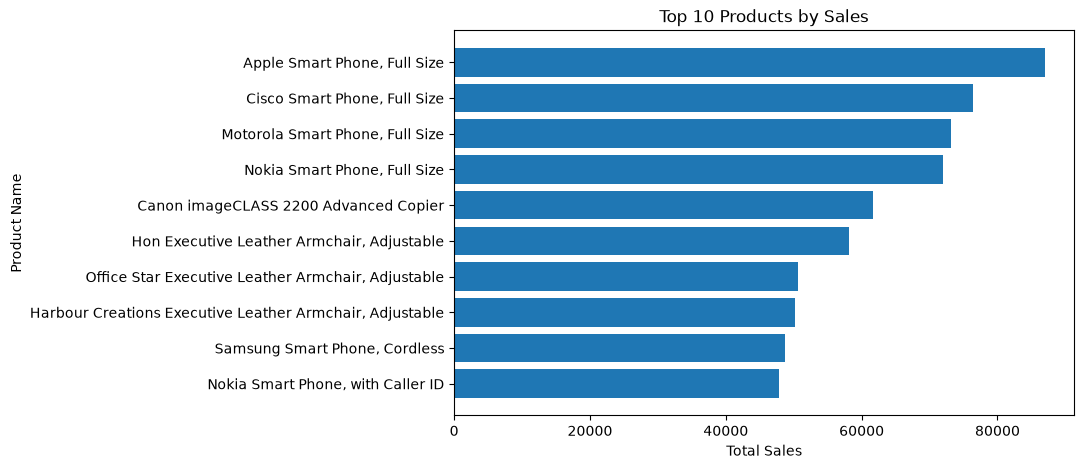

In [15]:
#4,top 10 products


top_products=store.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10).reset_index()
print(top_products)
plt.figure(figsize=(8, 5))
plt.barh(top_products['product_name'], top_products['sales'])
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.title('Top 10 Products by Sales')
plt.gca().invert_yaxis()
plt.show()

finding: The Top 10 product analysis helps identify products that could receive more attention in marketing, inventory planning, and promotions.

          category        profit
0       Technology  663778.73318
1  Office Supplies  518473.83430
2        Furniture  286782.25380


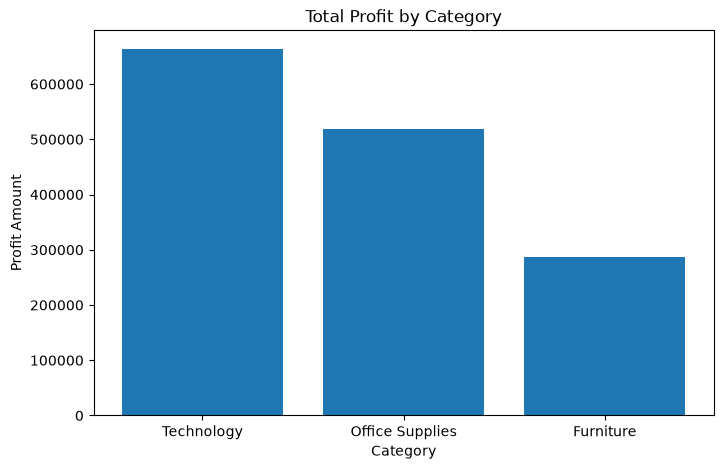

In [16]:
#5,Profit by Category

profit_by_category=store.groupby('category')['profit'].sum().sort_values(ascending=False).reset_index()
print(profit_by_category)
plt.figure(figsize=(8, 5))

plt.bar(profit_by_category['category'], profit_by_category['profit'])

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit Amount')
plt.show()

finding:This is important because the category with the highest sales doesn't necessarily have the highest profitability.

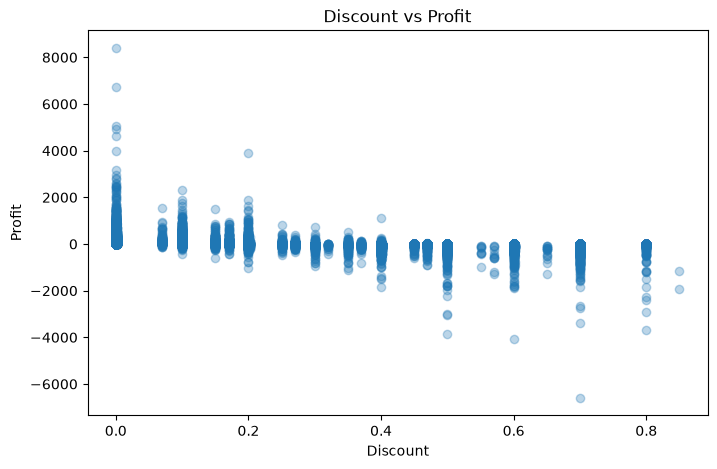

In [17]:
#6,Does Discount Affect Profit?

plt.figure(figsize=(8, 5))

plt.scatter(store['discount'], store['profit'], alpha=0.3)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

In [18]:
correlation=store['discount'].corr(store['profit'])
print(correlation)

-0.3163749562484045


finding:Correlation doesn't prove that discounts cause the lower profit.

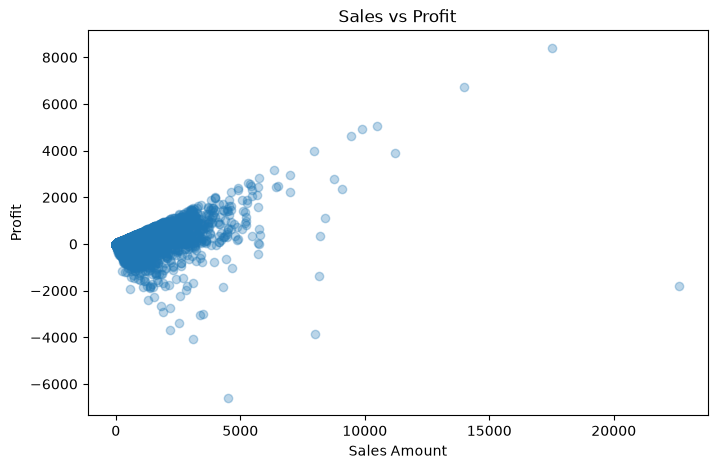

In [20]:
#7,sales vs profit

plt.figure(figsize=(8, 5))

plt.scatter(store['sales'], store['profit'], alpha=0.3)

plt.title('Sales vs Profit')
plt.xlabel('Sales Amount')
plt.ylabel('Profit')

plt.show()

In [21]:
sales_profit_correlation=store['sales'].corr(store['profit'])
print(sales_profit_correlation)

0.48594423985266755


There is a moderate positive relationship between sales and profit.

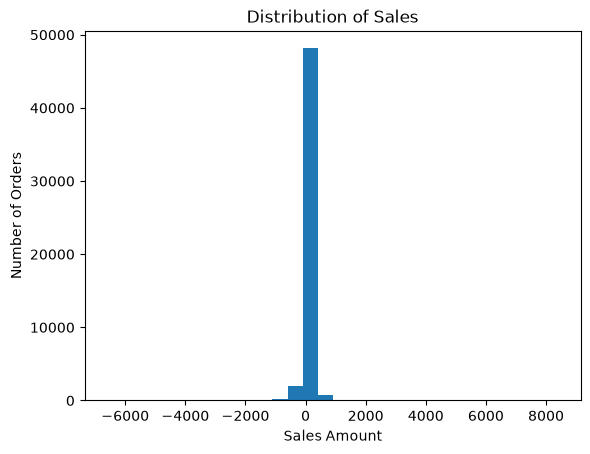

In [22]:
#8,how sales are distributed
plt.hist(store['profit'],bins=30)
plt.title('Distribution of Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Number of Orders')
plt.show()

finding:
Most orders have relatively low sales values, while a small number of orders have very large sales values.

   year      sales
0  2011  2259511.0
1  2012  2677493.0
2  2013  3405860.0
3  2014  4300041.0


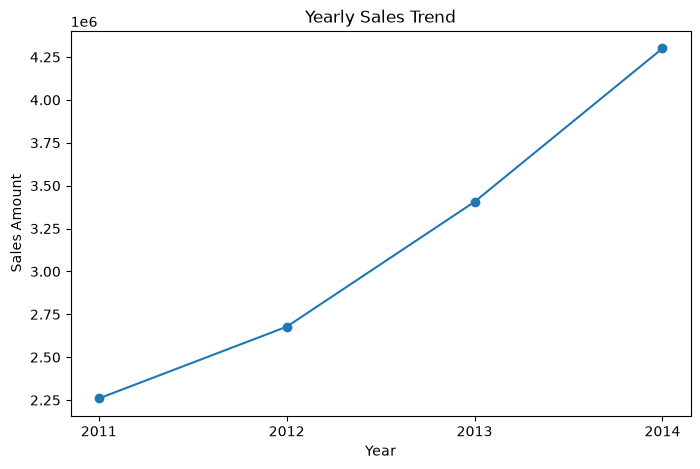

In [23]:
#9,sales by year
year_sales=store.groupby('year')['sales'].sum().reset_index()
print(year_sales)

plt.figure(figsize=(8, 5))

plt.plot(year_sales['year'], year_sales['sales'], marker='o')

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales Amount')

plt.xticks(year_sales['year'])

plt.show()

finding:2014 was the strongest year, and the dataset shows a clear upward sales trend.

Object `Profitable` not found.
            region        profit
0          Central  311403.98164
1            North  194597.95252
2       North Asia  165578.42100
3            South  140355.76618
4     Central Asia  132480.18700
5          Oceania  121666.64200
6             West  108418.44890
7             East   91522.78000
8           Africa   88871.63100
9             EMEA   43897.97100
10       Caribbean   34571.32104
11  Southeast Asia   17852.32900
12          Canada   17817.39000


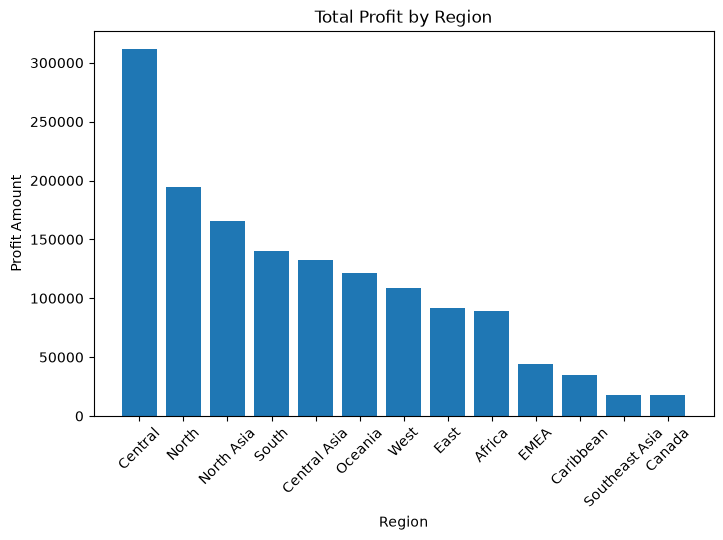

In [24]:
10 — Which Regions Are Actually Profitable?

profit_region=store.groupby('region')['profit'].sum().sort_values(ascending=False).reset_index()
print(profit_region)

plt.figure(figsize=(8, 5))

plt.bar(profit_region['region'], profit_region['profit'])

plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit Amount')
plt.xticks(rotation=45)

plt.show()

finding:Central is strong in both sales and profit, which makes it an especially important region.

# 4. Feature Engineering

In [26]:
#profit margin
store['profit_margin']=store['profit']/store['sales']*100
print(store['profit_margin'])


0        26.014706
1        30.030000
2        44.909091
3       -57.900000
4        33.131579
           ...    
51285    32.277143
51286    10.500000
51287    47.538462
51288     8.000000
51289   -20.160000
Name: profit_margin, Length: 51290, dtype: float64


In [27]:
print("Zero sales:", (store['sales'] == 0).sum())
print("Infinite margins:", np.isinf(store['profit_margin']).sum())

Zero sales: 1
Infinite margins: 1


In [28]:
# order value
store['order_value']=store['sales']/store['quantity']
print(store['order_value'].head())

0    204.0
1     40.0
2     16.5
3     15.0
4     22.8
Name: order_value, dtype: float64


In [29]:
# day of week

store['day_of_week']=store['order_date'].dt.day_name()
print(store['day_of_week'].value_counts())

day_of_week
Friday       8745
Tuesday      8654
Monday       8424
Thursday     8262
Wednesday    8203
Saturday     5639
Sunday       3363
Name: count, dtype: int64


In [30]:

#4,customer purchase frequency

store['customer_frequency']=store.groupby('customer_name')['order_id'].transform('nunique')

print(store[['customer_name','order_id','customer_frequency']])

          customer_name         order_id  customer_frequency
0       Toby Braunhardt     AG-2011-2040                  35
1           Joseph Holt    IN-2011-47883                  45
2         Annie Thurman     HU-2011-1220                  34
3          Eugene Moren  IT-2011-3647632                  36
4           Joseph Holt    IN-2011-47883                  45
...                 ...              ...                 ...
51285        Erica Bern   CA-2014-115427                  41
51286         Liz Preis     MO-2014-2560                  30
51287  Charlotte Melton   MX-2014-110527                  29
51288     Tamara Dahlen   MX-2014-114783                  28
51289     Jill Matthias   CA-2014-156720                  29

[51290 rows x 3 columns]


In [31]:
#customer total sales

store['customer_total_sales']=store.groupby('customer_name')['sales'].transform(sum)

print(store[['customer_name','sales','customer_total_sales']])

          customer_name  sales  customer_total_sales
0       Toby Braunhardt  408.0               11699.0
1           Joseph Holt  120.0               20939.0
2         Annie Thurman   66.0               13385.0
3          Eugene Moren   45.0               23411.0
4           Joseph Holt  114.0               20939.0
...                 ...    ...                   ...
51285        Erica Bern   14.0               16119.0
51286         Liz Preis    4.0               16611.0
51287  Charlotte Melton   26.0               12827.0
51288     Tamara Dahlen    7.0                7704.0
51289     Jill Matthias    3.0               14181.0

[51290 rows x 3 columns]


In [32]:
#6, Customer Average Order Value
store['customer_avg_order_value']=store['customer_total_sales']/store['customer_frequency']
print(store[['customer_name',
       'customer_total_sales',
       'customer_frequency',
       'customer_avg_order_value']].head(10))

      customer_name  customer_total_sales  customer_frequency  \
0   Toby Braunhardt               11699.0                  35   
1       Joseph Holt               20939.0                  45   
2     Annie Thurman               13385.0                  34   
3      Eugene Moren               23411.0                  36   
4       Joseph Holt               20939.0                  45   
5       Joseph Holt               20939.0                  45   
6   Magdelene Morse               21226.0                  31   
7       Kean Nguyen               18064.0                  34   
8      Ken Lonsdale               24127.0                  33   
9  Lindsay Williams               10982.0                  34   

   customer_avg_order_value  
0                334.257143  
1                465.311111  
2                393.676471  
3                650.305556  
4                465.311111  
5                465.311111  
6                684.709677  
7                531.294118  
8             

# 5. Customer Analysis & RFM

           customer_name  customer_total_sales
3316        Tom Ashbrook               40489.0
2019        Tamara Chand               37453.0
945            Greg Tran               35552.0
484   Christopher Conant               35187.0
1101         Sean Miller               35170.0
649         Bart Watters               32315.0
586     Natalie Fritzler               31778.0
2441        Fred Hopkins               30404.0
2202           Jane Waco               30288.0
257         Hunter Lopez               30246.0


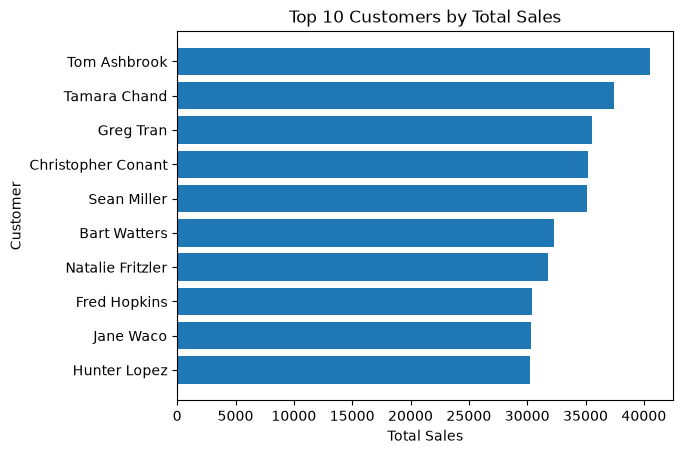

<Figure size 640x480 with 0 Axes>

In [33]:
#Step 1: Top Customers by Total Sales

top_customers=(
    store[['customer_name','customer_total_sales']]
    .drop_duplicates()
    .sort_values('customer_total_sales',ascending=False)
    .head(10)
)
print(top_customers)

plt.Figure(figsize=(10,6))
plt.barh(
    top_customers['customer_name'],
    top_customers['customer_total_sales']
)
plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer')
plt.gca().invert_yaxis()
plt.show()
plt.clf()

In [34]:
#customer frequency

frequent_customer=(
    store[['customer_name','customer_frequency']]
    .drop_duplicates()
    .sort_values('customer_frequency',ascending=False)
).head(10)
print(frequent_customer)

         customer_name  customer_frequency
351      Anna Andreadi                  47
294      Michael Paige                  47
330        Frank Olsen                  47
1127  Kristen Hastings                  46
667    Laura Armstrong                  46
1709    Sara Luxemburg                  46
649       Bart Watters                  45
1          Joseph Holt                  45
360    Patrick O'Brill                  45
2051   Tracy Blumstein                  45


          customer_name  customer_frequency  customer_total_sales
0       Toby Braunhardt                  35               11699.0
1           Joseph Holt                  45               20939.0
2         Annie Thurman                  34               13385.0
3          Eugene Moren                  36               23411.0
6       Magdelene Morse                  31               21226.0
...                 ...                 ...                   ...
6635       Maris LaWare                  33               15175.0
6709      Robert Marley                  27               12868.0
7161    Chad Cunningham                  30               12522.0
7243       Adrian Shami                  24               11287.0
7983  Giulietta Baptist                  30               12570.0

[795 rows x 3 columns]


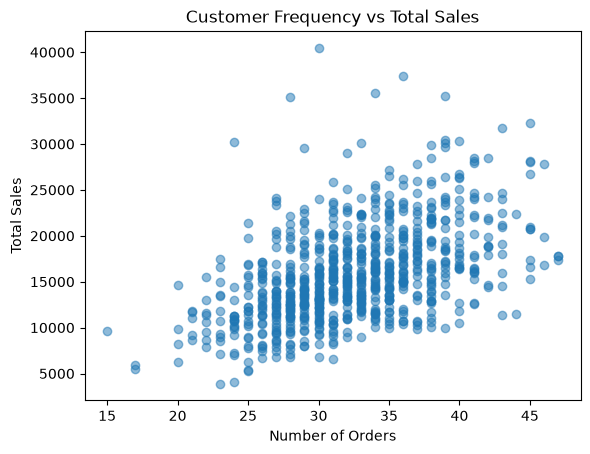

<Figure size 640x480 with 0 Axes>

In [36]:
#customer spending vs frequency

customer_summary = (
    store[['customer_name', 'customer_frequency', 'customer_total_sales']]
    .drop_duplicates()
)

print(customer_summary)

plt.Figure(figsize=(10,7))
plt.scatter(
    customer_summary['customer_frequency'],
    customer_summary['customer_total_sales'],
    alpha=0.5
)
plt.title('Customer Frequency vs Total Sales')
plt.xlabel('Number of Orders')
plt.ylabel('Total Sales')
plt.show()
plt.clf()

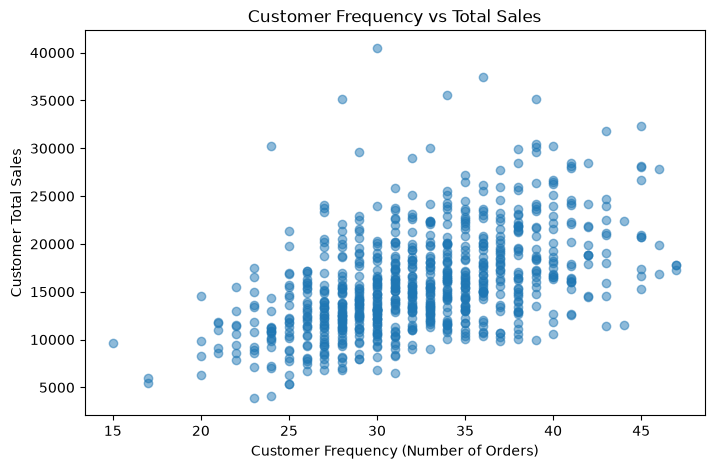

In [37]:
#4,Analyze Customer Frequency vs Sales
plt.figure(figsize=(8, 5))

plt.scatter(
    customer_summary['customer_frequency'],
    customer_summary['customer_total_sales'],
    alpha=0.5
)

plt.title('Customer Frequency vs Total Sales')
plt.xlabel('Customer Frequency (Number of Orders)')
plt.ylabel('Customer Total Sales')
plt.show()

RFM Analysis

In [38]:
#recency

recency_date=store['order_date'].max()
print(recency_date)

2014-12-31 00:00:00


In [39]:
customer_recency_date=(
    recency_date - store.groupby('customer_name')['order_date'].max()
).dt.days

print(customer_recency_date)

customer_name
Aaron Bergman         16
Aaron Hawkins         12
Aaron Smayling        26
Adam Bellavance       25
Adam Hart              2
                      ..
Xylona Preis          43
Yana Sorensen          4
Yoseph Carroll         4
Zuschuss Carroll       3
Zuschuss Donatelli     1
Name: order_date, Length: 795, dtype: int64


In [40]:
#frequency & monetary
rfm=pd.DataFrame({
    'Recency':customer_recency_date,
    'Frequency':store.groupby('customer_name')['order_date'].nunique()
})

customer_monetary= store.groupby('customer_name')['sales'].sum()
rfm['Monetry']=customer_monetary

print(rfm)


                    Recency  Frequency  Monetry
customer_name                                  
Aaron Bergman            16         37  24646.0
Aaron Hawkins            12         34  20759.0
Aaron Smayling           26         31  14207.0
Adam Bellavance          25         39  20189.0
Adam Hart                 2         40  21720.0
...                     ...        ...      ...
Xylona Preis             43         30  12202.0
Yana Sorensen             4         31  20034.0
Yoseph Carroll            4         30  20165.0
Zuschuss Carroll          3         37  28485.0
Zuschuss Donatelli        1         29  12434.0

[795 rows x 3 columns]


In [41]:
rfm['R_score']=pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['f_score']=pd.qcut(rfm['Frequency'],5,labels=[1,2,3,4,5])
rfm['m_score']=pd.qcut(rfm['Monetry'],5,labels=[1,2,3,4,5])
print(rfm)

                    Recency  Frequency  Monetry R_score f_score m_score
customer_name                                                          
Aaron Bergman            16         37  24646.0       3       5       5
Aaron Hawkins            12         34  20759.0       4       4       5
Aaron Smayling           26         31  14207.0       2       3       3
Adam Bellavance          25         39  20189.0       2       5       5
Adam Hart                 2         40  21720.0       5       5       5
...                     ...        ...      ...     ...     ...     ...
Xylona Preis             43         30  12202.0       1       2       2
Yana Sorensen             4         31  20034.0       5       3       5
Yoseph Carroll            4         30  20165.0       5       2       5
Zuschuss Carroll          3         37  28485.0       5       5       5
Zuschuss Donatelli        1         29  12434.0       5       2       2

[795 rows x 6 columns]


In [43]:
rfm['segment'] = 'others'

#Best Customers
rfm.loc[
    (rfm["R_score"] >= 4) &
    (rfm["f_score"] >= 4) &
    (rfm["m_score"] >= 4),
    'segment'
] = "Best customers"


#Loyal Customers
rfm.loc[
    (rfm['f_score'] >= 4) &
    (rfm['m_score'] >= 3) &
    (rfm['segment'] == 'others'),
    'segment'
] = 'loyal_customers'


#At Risk
rfm.loc[
    (rfm['R_score'] <= 2) &
    (rfm['f_score'] >= 3) &
    (rfm['segment'] == 'others'),
    'segment'
] = 'At Risk'


#Lost Customers
rfm.loc[
    (rfm['R_score'] <= 2) &
    (rfm['f_score'] <= 2) &
    (rfm['segment'] == 'others'),
    'segment'
] = 'Lost Customers'

print(rfm.head())

                 Recency  Frequency  Monetry R_score f_score m_score  \
customer_name                                                          
Aaron Bergman         16         37  24646.0       3       5       5   
Aaron Hawkins         12         34  20759.0       4       4       5   
Aaron Smayling        26         31  14207.0       2       3       3   
Adam Bellavance       25         39  20189.0       2       5       5   
Adam Hart              2         40  21720.0       5       5       5   

                         segment  
customer_name                     
Aaron Bergman     Best customers  
Aaron Hawkins     Best customers  
Aaron Smayling           At Risk  
Adam Bellavance   Best customers  
Adam Hart        loyal_customers  


In [44]:
segment_summary=rfm['segment'].value_counts().reset_index()
segment_summary.columns = ['segment', 'customer_count']
segment_summary['percentage']=segment_summary['customer_count']/segment_summary['customer_count'].sum()*100
segment_summary['percentage']=segment_summary['percentage'].round(0)
print(segment_summary)

           segment  customer_count  percentage
0   Lost Customers             271        34.0
1          At Risk             178        22.0
2   Best customers             139        17.0
3           others             110        14.0
4  loyal_customers              97        12.0


#### 1,Customer retention problem 


34% Lost + 22% At Risk = 56%


More than half of the customers are in groups that need attention.


This suggests the business may have a **customer retention problem**.

#### 2,Find customers you can win back 

The At Risk group is particularly interesting.

They have shown purchasing behavior before, but their recent activity is low.

Instead of spending money finding completely new customers, the company can try to reactivate these customers.

#### 3,ind customers who need a win-back campaign 

The Lost Customers group can be targeted with a different strategy:

"We haven't seen you in a while. Here's a special offer."

But you don't necessarily want to spend the same amount on every lost customer

In [ ]:
segment_revenue= rfm.groupby('segment')['Monetry'].sum().sort_values(ascending=False)
print(segment_revenue)


segment
Lost Customers     3647496.0
Best customers     2920921.0
At Risk            2709537.0
loyal_customers    1792061.0
others             1572890.0
Name: Monetry, dtype: float64


In [47]:
segment_revenue_pct = (
    segment_revenue / rfm['Monetry'].sum() * 100
).round(2)

print(segment_revenue_pct)

segment
Lost Customers     28.85
Best customers     23.10
At Risk            21.43
loyal_customers    14.17
others             12.44
Name: Monetry, dtype: float64


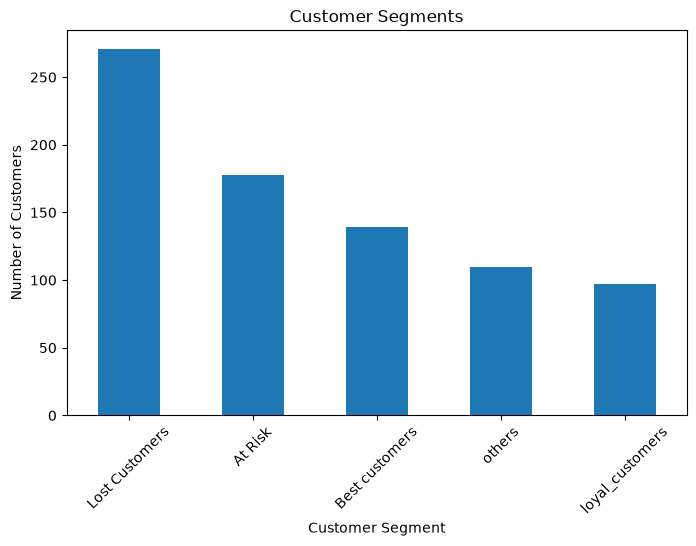

In [48]:
import matplotlib.pyplot as plt

segment_counts = rfm['segment'].value_counts()

plt.figure(figsize=(8, 5))
segment_counts.plot(kind='bar')

plt.title('Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

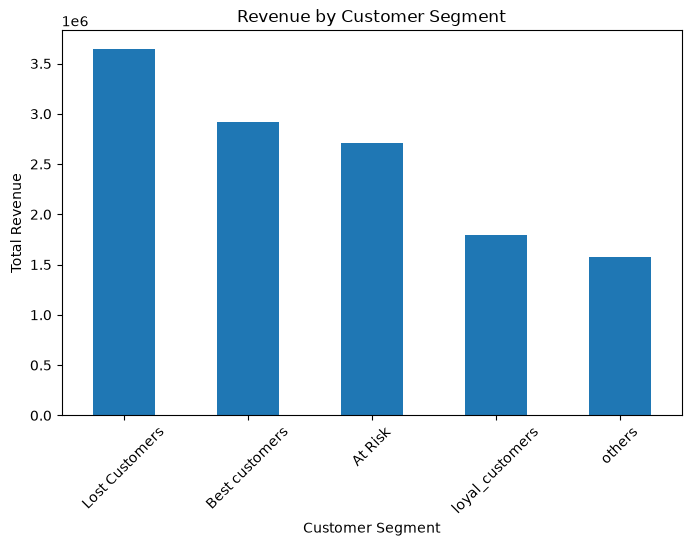

In [49]:
segment_revenue.plot(kind='bar', figsize=(8, 5))

plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

# 6. Machine Learning

In [50]:
store['is_profitable']=(store['profit'] > 0).astype(int)
print(store.head())


          order_id order_date  ship_date       ship_mode    customer_name  \
0     AG-2011-2040 2011-01-01 2011-06-01  Standard Class  Toby Braunhardt   
1    IN-2011-47883 2011-01-01 2011-08-01  Standard Class      Joseph Holt   
2     HU-2011-1220 2011-01-01 2011-05-01    Second Class    Annie Thurman   
3  IT-2011-3647632 2011-01-01 2011-05-01    Second Class     Eugene Moren   
4    IN-2011-47883 2011-01-01 2011-08-01  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

  order_priority  year month profit_margin  order_value  day_of_week  \
0         Medium  2011     1     26.014706        204.0 

In [51]:

print(store['is_profitable'].value_counts())

is_profitable
1    38079
0    13211
Name: count, dtype: int64


In [52]:

features=['sales',
    'quantity','discount','shipping_cost','order_value',
    'customer_frequency','customer_avg_order_value']

In [53]:
X = store[features]
y = store['is_profitable']

print(X)
print(y)

       sales  quantity  discount  shipping_cost  order_value  \
0      408.0         2       0.0          35.46   204.000000   
1      120.0         3       0.1           9.72    40.000000   
2       66.0         4       0.0           8.17    16.500000   
3       45.0         3       0.5           4.82    15.000000   
4      114.0         5       0.1           4.70    22.800000   
...      ...       ...       ...            ...          ...   
51285   14.0         2       0.2           0.89     7.000000   
51286    4.0         1       0.0           0.49     4.000000   
51287   26.0         3       0.0           0.35     8.666667   
51288    7.0         1       0.0           0.20     7.000000   
51289    3.0         3       0.2           0.17     1.000000   

       customer_frequency  customer_avg_order_value  
0                      35                334.257143  
1                      45                465.311111  
2                      34                393.676471  
3              

In [54]:
from sklearn.model_selection import train_test_split


In [56]:
x_train,x_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=2,stratify=y)

In [57]:
print("training data",x_train.shape)
print("test data",x_test.shape)

training data (41032, 7)
test data (10258, 7)


In [58]:
from  sklearn.linear_model import LogisticRegression

In [59]:
model=LogisticRegression(max_iter=1000,random_state=42)
model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [60]:
#“Is this order profitable or not?”
y_pred=model.predict(x_test)
print(y_pred[:10])

[0 1 1 1 1 1 1 0 1 1]


In [61]:
from sklearn.metrics import accuracy_score

lg_accuracy_score=accuracy_score(y_test,y_pred)
print(lg_accuracy_score)

0.9186976018717099


In [62]:
from sklearn.metrics import classification_report

classification_report=classification_report(y_test,y_pred)
print(classification_report)

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      2642
           1       0.92      0.97      0.95      7616

    accuracy                           0.92     10258
   macro avg       0.91      0.87      0.89     10258
weighted avg       0.92      0.92      0.92     10258



In [63]:
from sklearn.metrics import confusion_matrix

confusion_matrix=confusion_matrix(y_test,y_pred)
print(confusion_matrix)

[[2032  610]
 [ 224 7392]]


Our Logistic Regression accuracy is already 91.64%, which is good.

#### 2,DECISION TREE

In [64]:
from sklearn.tree import DecisionTreeClassifier

In [65]:
tree_model=DecisionTreeClassifier(max_depth=5,random_state=42)
tree_model.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [66]:
tree_pred=tree_model.predict(x_test)

In [67]:
from sklearn.metrics import accuracy_score
tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.9192825112107623


In [68]:
from sklearn.metrics import classification_report
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      2642
           1       0.92      0.97      0.95      7616

    accuracy                           0.92     10258
   macro avg       0.91      0.87      0.89     10258
weighted avg       0.92      0.92      0.92     10258



Decision Tree performed slightly better than Logistic Regression, achieving 91.93% accuracy compared with 91.64%. It also improved recall for unprofitable orders from 76% to 77%.

In [70]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [71]:
rf_pred=model.predict(x_test)
print(rf_pred[:10])

[1 1 1 1 1 1 1 0 1 1]


In [72]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.918892571651394


In [73]:
rf_classification_report=classification_report(y_test,rf_pred)
print(rf_classification_report)

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      2642
           1       0.92      0.97      0.95      7616

    accuracy                           0.92     10258
   macro avg       0.91      0.87      0.89     10258
weighted avg       0.92      0.92      0.92     10258



In [74]:
from sklearn.metrics import confusion_matrix
ef_cm=confusion_matrix(y_test,rf_pred)
print(ef_cm)

[[2038  604]
 [ 228 7388]]


The three models are extremely close, with Decision Tree slightly ahead at 91.93% accuracy.

In [77]:
#feature importance


feature_importance=pd.DataFrame({
    "Features":features,
    'Importance':tree_model
    .feature_importances_
})
feature_importance=feature_importance.sort_values('Importance',ascending=False)
print(feature_importance)

                   Features  Importance
2                  discount    0.986821
4               order_value    0.011862
0                     sales    0.001151
5        customer_frequency    0.000103
6  customer_avg_order_value    0.000064
1                  quantity    0.000000
3             shipping_cost    0.000000


"Discount is the strongest predictive feature in our model, and higher discounts are associated with lower profitability."


In [78]:
#model comparison 

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lg_accuracy_score,
        tree_accuracy,
        rf_accuracy
    ]
})

print(model_comparison)

                 Model  Accuracy
0  Logistic Regression  0.918698
1        Decision Tree  0.919283
2        Random Forest  0.918893


# 7. Sales Forecasting

In [80]:
#prepare monthly sales 

monthly_sales=(
    store.groupby(['year','month'])['sales']
    .sum()
    .reset_index()
)
print(monthly_sales.head())

   year  month     sales
0  2011      1  138245.0
1  2011      2  134969.0
2  2011      3  171445.0
3  2011      4  128843.0
4  2011      5  148158.0


In [81]:
monthly_sales['date']=pd.to_datetime(monthly_sales[['year','month']].assign(day=1))
print(monthly_sales.head())

   year  month     sales       date
0  2011      1  138245.0 2011-01-01
1  2011      2  134969.0 2011-02-01
2  2011      3  171445.0 2011-03-01
3  2011      4  128843.0 2011-04-01
4  2011      5  148158.0 2011-05-01


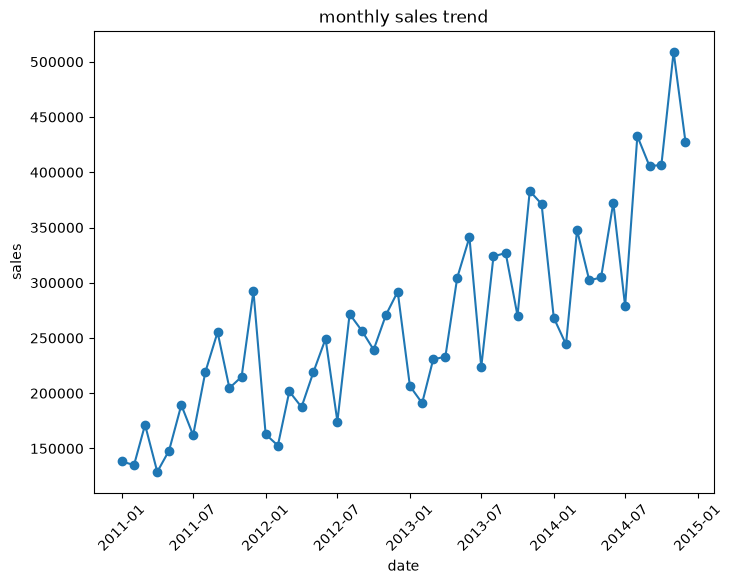

In [82]:
plt.figure(figsize=(8,6))

plt.plot(
    monthly_sales["date"],
    monthly_sales['sales'],
    marker='o'
)

plt.title('monthly sales trend')

plt.xlabel('date')
plt.ylabel('sales')
plt.xticks(rotation=45)

plt.show()

#### Finding
### 1, Overall upward trend

Sales were around 130K–190K in early 2011, but by 2014 many months are above 300K–400K.
So overall, sales are growing over time.
#### 2,Sales fluctuate a lot

For example, sales can jump from around 250K to 290K and then fall again. So the trend isn't a straight line.
#### 3, Some high-sales months

The biggest visible peak is around late 2014, at 500K+.

Monthly sales show an overall upward trend from 2011 to 2014.
However, sales fluctuate considerably from month to month, with
several high-sales peaks during 2014. This indicates that both
long-term growth and monthly variation are present in the data.

In [84]:
#3-Month Moving Average  

monthly_sales['moving_avg']=monthly_sales['sales'].rolling(window=3).mean()
print(monthly_sales.head())

   year  month     sales       date     moving_avg
0  2011      1  138245.0 2011-01-01            NaN
1  2011      2  134969.0 2011-02-01            NaN
2  2011      3  171445.0 2011-03-01  148219.666667
3  2011      4  128843.0 2011-04-01  145085.666667
4  2011      5  148158.0 2011-05-01  149482.000000


In [85]:
monthly_sales['forcasting']=monthly_sales['sales'].rolling(window=3).mean().shift(1)
print(monthly_sales.head(10))

   year  month     sales       date     moving_avg     forcasting
0  2011      1  138245.0 2011-01-01            NaN            NaN
1  2011      2  134969.0 2011-02-01            NaN            NaN
2  2011      3  171445.0 2011-03-01  148219.666667            NaN
3  2011      4  128843.0 2011-04-01  145085.666667  148219.666667
4  2011      5  148158.0 2011-05-01  149482.000000  145085.666667
5  2011      6  189339.0 2011-06-01  155446.666667  149482.000000
6  2011      7  162039.0 2011-07-01  166512.000000  155446.666667
7  2011      8  219236.0 2011-08-01  190204.666667  166512.000000
8  2011      9  255250.0 2011-09-01  212175.000000  190204.666667
9  2011     10  204679.0 2011-10-01  226388.333333  212175.000000


In [86]:
from sklearn.metrics import mean_absolute_error

In [87]:
forecast_data = monthly_sales.dropna(subset=['forcasting'])
mae=mean_absolute_error(forecast_data['sales'],
                        forecast_data['forcasting'])
print("Mean Absolute Error:", mae)

Mean Absolute Error: 43265.666666666664


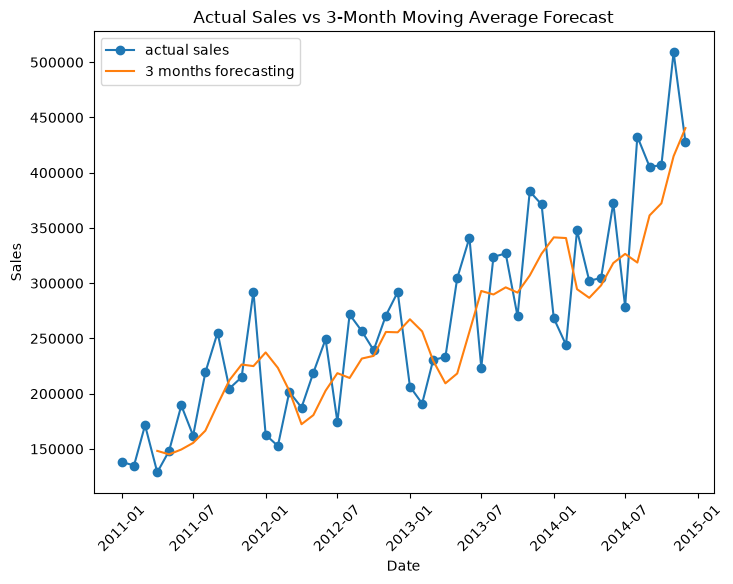

In [88]:
plt.figure(figsize=(8,6))

plt.plot(monthly_sales['date'],
         monthly_sales['sales'],
         label='actual sales',
         marker='o')

plt.plot(
    monthly_sales['date'],
    monthly_sales['forcasting'],
    label='3 months forecasting'
)

plt.title('Actual Sales vs 3-Month Moving Average Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.show()

#### Finding

The 3-month moving average captures the overall upward trend in
sales but smooths out short-term fluctuations. The forecast also
lags behind sudden changes in actual sales, which limits its ability
to predict sharp increases or decreases in monthly sales.


#### Linear Regression Forecasting

In [89]:
monthly_sales['time_index']=range(len(monthly_sales))
print(monthly_sales[['date','sales','time_index']].head())

        date     sales  time_index
0 2011-01-01  138245.0           0
1 2011-02-01  134969.0           1
2 2011-03-01  171445.0           2
3 2011-04-01  128843.0           3
4 2011-05-01  148158.0           4


In [91]:
from sklearn.linear_model import LinearRegression

In [92]:
lr_model=LinearRegression()

x_time=monthly_sales[['time_index']]
y_sales=monthly_sales['sales']

lr_model.fit(x_time,y_sales)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[5342.2]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['time_index']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.379e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [93]:
monthly_sales['lr_predict']=lr_model.predict(monthly_sales[['time_index']])

In [94]:
print(monthly_sales.head(10))

   year  month     sales       date     moving_avg     forcasting  time_index  \
0  2011      1  138245.0 2011-01-01            NaN            NaN           0   
1  2011      2  134969.0 2011-02-01            NaN            NaN           1   
2  2011      3  171445.0 2011-03-01  148219.666667            NaN           2   
3  2011      4  128843.0 2011-04-01  145085.666667  148219.666667           3   
4  2011      5  148158.0 2011-05-01  149482.000000  145085.666667           4   
5  2011      6  189339.0 2011-06-01  155446.666667  149482.000000           5   
6  2011      7  162039.0 2011-07-01  166512.000000  155446.666667           6   
7  2011      8  219236.0 2011-08-01  190204.666667  166512.000000           7   
8  2011      9  255250.0 2011-09-01  212175.000000  190204.666667           8   
9  2011     10  204679.0 2011-10-01  226388.333333  212175.000000           9   

      lr_predict  
0  137852.212585  
1  143194.410099  
2  148536.607613  
3  153878.805127  
4  159221.002

mean absolute error : 39304.61994469774


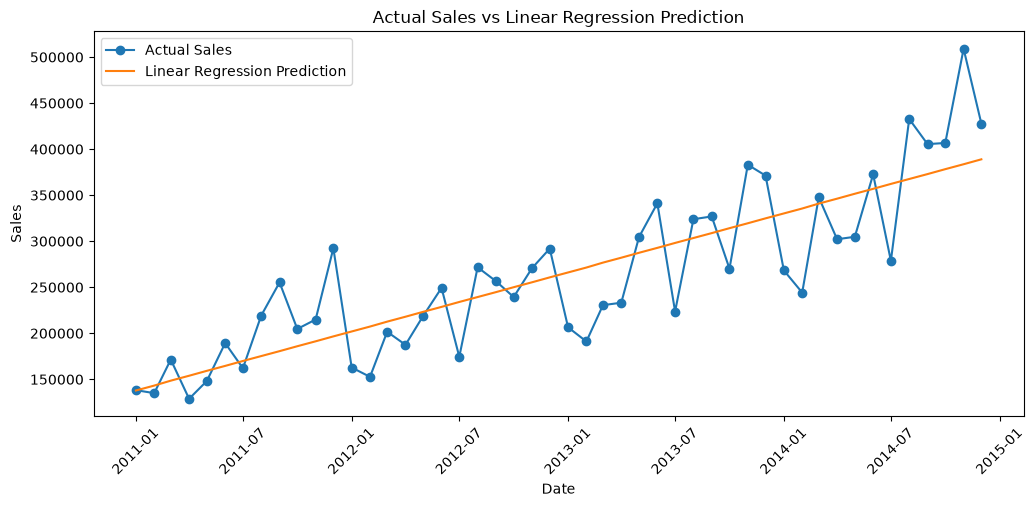

In [96]:
lr_mae=mean_absolute_error(monthly_sales['sales']
    ,monthly_sales['lr_predict'])
print('mean absolute error :',lr_mae)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['date'],
    monthly_sales['sales'],
    label='Actual Sales',
    marker='o'
)

plt.plot(
    monthly_sales['date'],
    monthly_sales['lr_predict'],
    label='Linear Regression Prediction'
)

plt.title('Actual Sales vs Linear Regression Prediction')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.show()

#### Forecasting Finding

Monthly sales showed a clear long-term upward trend from 2011 to
2014, with considerable month-to-month fluctuations. A 3-month
moving average produced an MAE of 43,265.67, while Linear Regression
achieved a lower MAE of 39,304.62.

Therefore, Linear Regression performed better than the simple
moving-average baseline at capturing the overall sales trend.
However, it was not able to capture short-term monthly fluctuations
and sudden sales peaks effectively.

# 8. Business Insights & Recommendations

### Business Insight 1 — Category Performance

Technology generated the highest total sales among the three
categories, followed by Furniture and Office Supplies. The business
should prioritize high-performing Technology products while also
evaluating their profitability before increasing inventory or
marketing investment.

### Business Insight 2 — Regional Performance

The Central region generated the highest total sales and total profit
in the dataset. This indicates strong overall performance in the
region. The business should maintain its investment in Central while
examining the successful products and strategies that could be
applied to lower-performing regions.

### Business Insight 3 — Discount and Profitability

The analysis found a negative relationship between discount and
profit, with a correlation of -0.3164. In addition, discount was
the strongest predictive feature in the Decision Tree model,
accounting for approximately 98.68% of feature importance.

The business should therefore review its discount strategy and
evaluate profitability before offering large discounts. However,
the analysis shows association rather than proving that discounts
directly cause losses.

### Business Insight 4 — Sales and Profitability

Sales and profit showed a moderate positive correlation of 0.4859,
indicating that higher sales are generally associated with higher
profit. However, some high-sales orders still generated negative
profit.

Therefore, the business should evaluate both revenue and
profitability when making decisions rather than focusing only on
increasing sales.

### Business Insight 5 — Customer Segmentation

RFM analysis was used to segment customers based on Recency,
Frequency, and Monetary value. The analysis identified groups such
as Best Customers, Loyal Customers, Potential Customers, At Risk,
and Lost Customers.

This segmentation can help the business create targeted customer
strategies instead of treating all customers equally. High-value
customers can be rewarded and at-risk customers can be targeted
with appropriate retention campaigns.

### Business Insight 6 — Sales Forecasting

Historical sales showed a clear upward trend from 2011 to 2014.
A 3-month moving average produced an MAE of 43,265.67, while
Linear Regression achieved a lower MAE of 39,304.62.

Linear Regression therefore performed better than the moving-average
baseline at capturing the overall sales trend. However, it did not
capture short-term fluctuations and sudden monthly peaks effectively.

The business can use the observed sales trend to support sales
planning, inventory decisions, and future target setting.

### Business Insight 7 — Top Products

The Top 10 products by total sales represent the products that
generate the highest revenue in the dataset. These products can be
prioritized for inventory planning, marketing, and stock management.

However, sales alone should not determine business decisions.
Product-level profitability should also be evaluated to identify
products that are both high-selling and profitable.

# Final Project Conclusion

This project analyzed over 51,000 sales transactions to understand
sales performance, profitability, customer behavior, and future
sales trends.

The analysis found that Technology generated the highest total
sales, while the Central region generated both the highest sales
and highest total profit. The analysis also showed a negative
relationship between discount and profit, suggesting that higher
discounts are generally associated with lower profitability.

Customer analysis and RFM segmentation helped identify different
customer groups based on purchasing behavior, allowing businesses
to develop more targeted customer strategies.

For profitability prediction, Logistic Regression, Decision Tree,
and Random Forest models were evaluated. The Decision Tree achieved
the highest accuracy at 91.93%, although the three models performed
very similarly. Discount was the dominant predictive feature in the
Decision Tree.

For sales forecasting, a 3-month moving average was compared with
Linear Regression. Linear Regression achieved a lower MAE of
39,304.62 compared with 43,265.67 for the moving-average baseline,
indicating better performance at capturing the overall sales trend.

Overall, this project demonstrates how data science can be used to
transform raw sales data into actionable business insights,
including product strategy, regional planning, customer
segmentation, profitability analysis, and sales forecasting.

# 9. Final Conclusion

## Key Results

- Analyzed **51,290 sales transactions** across multiple years.
- **Technology** generated the highest total sales.
- **Central** was the strongest region in both total sales and profit.
- Discount had a **negative relationship with profit** (correlation: -0.3164).
- **Decision Tree** achieved the highest classification accuracy: **91.93%**.
- **Discount** was the dominant predictive feature in the Decision Tree.
- **Linear Regression** achieved an MAE of **39,304.62**, outperforming the 3-month moving-average baseline of **43,265.67**.
- RFM analysis identified customer segments based on **Recency, Frequency, and Monetary value**.